In [1]:
!pip install tensorflow scikit-learn pandas matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data, columns=housing.feature_names)

data['PRICE'] = housing.target

print(data.head())

print("\nShape of Dataset:")
print(data.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Shape of Dataset:
(20640, 9)


In [4]:
print(data.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64


In [5]:
print(data.describe())

print("\nDataset Info:\n")
print(data.info())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         PRICE  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

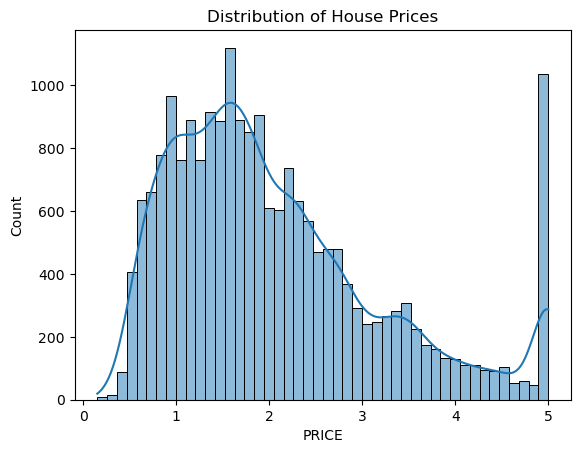

In [6]:
sns.histplot(data['PRICE'], kde=True)

plt.title("Distribution of House Prices")

plt.show()

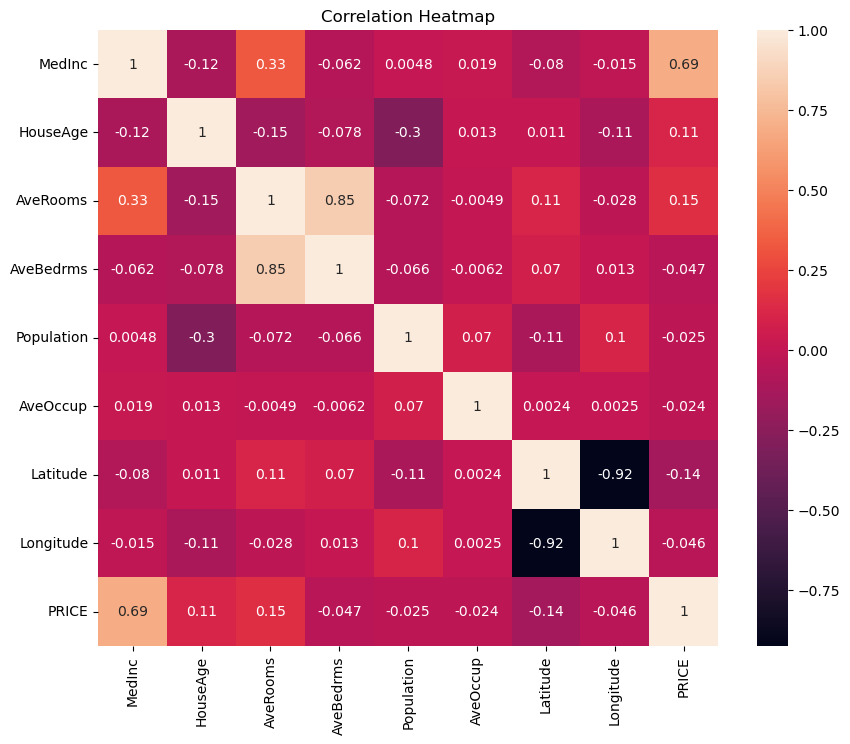

In [7]:
correlation = data.corr()

plt.figure(figsize=(10,8))

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")

plt.show()

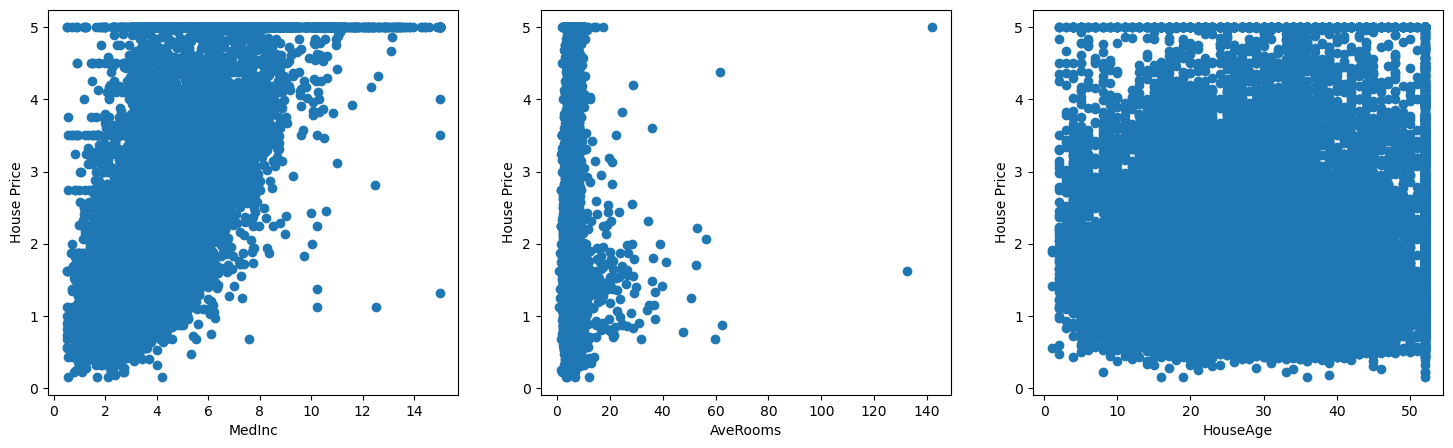

In [8]:
features = ['MedInc', 'AveRooms', 'HouseAge']

plt.figure(figsize=(18,5))

for i, col in enumerate(features):

    plt.subplot(1, len(features), i+1)

    plt.scatter(data[col], data['PRICE'])

    plt.xlabel(col)

    plt.ylabel("House Price")

plt.show()

In [9]:
X = data.drop('PRICE', axis=1)

y = data['PRICE']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Data normalized successfully")

Data normalized successfully


In [11]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)

mae_lr = mean_absolute_error(y_test, y_pred_lr)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")

print("MSE:", mse_lr)

print("MAE:", mae_lr)

print("R2 Score:", r2_lr)

Linear Regression Results
MSE: 0.5558915986952442
MAE: 0.5332001304956566
R2 Score: 0.575787706032451


In [12]:
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))

model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(16, activation='relu'))

model.add(Dense(1))

model.summary()

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_split=0.1
)

Epoch 1/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.7220 - mae: 0.5824 - val_loss: 0.4217 - val_mae: 0.4585
Epoch 2/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3755 - mae: 0.4324 - val_loss: 0.3865 - val_mae: 0.4303
Epoch 3/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3386 - mae: 0.4092 - val_loss: 0.3618 - val_mae: 0.4256
Epoch 4/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3273 - mae: 0.4005 - val_loss: 0.3418 - val_mae: 0.4080
Epoch 5/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3149 - mae: 0.3902 - val_loss: 0.3969 - val_mae: 0.4252
Epoch 6/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3081 - mae: 0.3864 - val_loss: 0.3322 - val_mae: 0.3999
Epoch 7/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2970 - mae: 0.3775 - val_loss: 0.3464 - val_mae: 0.3901
Epoch 8/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2938 - mae: 0.3746 - val_loss: 0.3073 - val_mae: 0.3852
Epoch 9/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - lo

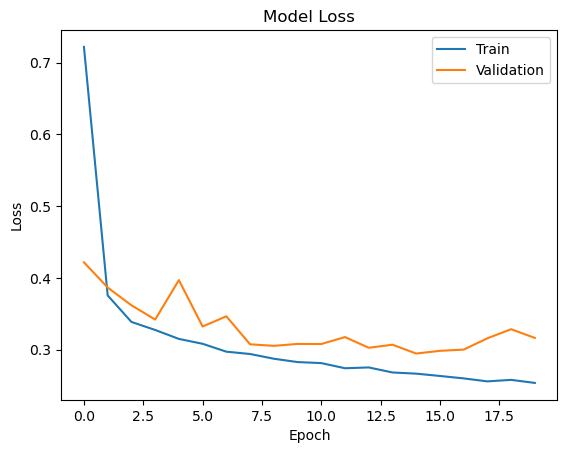

In [15]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [16]:
y_pred_nn = model.predict(X_test)

mse_nn = mean_squared_error(y_test, y_pred_nn)

mae_nn = mean_absolute_error(y_test, y_pred_nn)

r2_nn = r2_score(y_test, y_pred_nn)

print("Neural Network Results")

print("MSE:", mse_nn)

print("MAE:", mae_nn)

print("R2 Score:", r2_nn)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Neural Network Results
MSE: 0.29334735003532236
MAE: 0.36556001446177333
R2 Score: 0.7761406134219917


In [17]:
new_data = [[8.0, 40.0, 6.0, 1.0, 500.0, 3.0, 34.0, -118.0]]

new_data = scaler.transform(new_data)

prediction = model.predict(new_data)

print("Predicted House Price:", prediction)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
Predicted House Price: [[3.090876]]
